# Healthcare Provider Fraud Detection

## Submitted by

Name: Appaji gouda

## Problem Statement

The objective of this project is to identify potentially fraudulent healthcare providers based on inpatient claims, outpatient claims, and beneficiary information.

The primary goal is to build a robust machine-learning system capable of detecting suspicious provider behavior while minimizing false positives.

The solution includes:

- Data collection
- Data cleaning
- Exploratory data analysis
- Feature engineering
- Model building
- Model interpretation
- Business recommendations
- Streamlit deployment

# Business Understanding

Healthcare fraud is one of the biggest challenges in the insurance industry.

Common fraud patterns include:

- Duplicate claims
- Incorrect billing
- Unnecessary procedures
- Inflated reimbursements
- Misrepresentation of services

The objective is to identify potentially fraudulent providers by analyzing:

- Patient information
- Diagnosis codes
- Physician information
- Claim amounts
- Hospital stay duration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
train = pd.read_csv(
    "data/Train-1542865627584.csv"
)

beneficiary = pd.read_csv(
    "data/Train_Beneficiarydata-1542865627584.csv"
)

inpatient = pd.read_csv(
    "data/Train_Inpatientdata-1542865627584.csv"
)

outpatient = pd.read_csv(
    "data/Train_Outpatientdata-1542865627584.csv"
)

In [3]:
print("Train:", train.shape)
print("Beneficiary:", beneficiary.shape)
print("Inpatient:", inpatient.shape)
print("Outpatient:", outpatient.shape)

Train: (5410, 2)
Beneficiary: (138556, 25)
Inpatient: (40474, 30)
Outpatient: (517737, 27)


In [4]:
train.head()

,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes
2,PRV51004,No
3,PRV51005,Yes
4,PRV51007,No


In [5]:
beneficiary.head()

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,1,2,2,2,2,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,1,1,2,2,2,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,2,2,2,2,1,2,1,2,2,2,2,0,0,1790,1200


In [6]:
inpatient.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


In [7]:
outpatient.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11002,CLM624349,2009-10-11,2009-10-11,PRV56011,30,PHY326117,NaN,NaN,78943,V5866,V1272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,56409
1,BENE11003,CLM189947,2009-02-12,2009-02-12,PRV57610,80,PHY362868,NaN,NaN,6115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,79380
2,BENE11003,CLM438021,2009-06-27,2009-06-27,PRV57595,10,PHY328821,NaN,NaN,2723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,BENE11004,CLM121801,2009-01-06,2009-01-06,PRV56011,40,PHY334319,NaN,NaN,71988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
4,BENE11004,CLM150998,2009-01-22,2009-01-22,PRV56011,200,PHY403831,NaN,NaN,82382,30000,72887,4280,7197,V4577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,71947


# Data Understanding

The dataset consists of four independent data sources.

1. Beneficiary data
2. Inpatient claims data
3. Outpatient claims data
4. Provider fraud labels

The goal is to identify providers that exhibit fraudulent behaviour by analysing their claim patterns, reimbursement amounts, diagnosis codes, physician information, and patient characteristics.

# Data Cleaning

The objective of this phase is to identify and address inconsistencies, duplicate values, missing values, invalid data types, and anomalies within the dataset.

This step ensures that the model receives high-quality data and produces reliable predictions.

In [8]:
print("Train:", train.shape)
print("Beneficiary:", beneficiary.shape)
print("Inpatient:", inpatient.shape)
print("Outpatient:", outpatient.shape)

Train: (5410, 2)
Beneficiary: (138556, 25)
Inpatient: (40474, 30)
Outpatient: (517737, 27)


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5410 entries, 0 to 5409
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Provider        5410 non-null   object
 1   PotentialFraud  5410 non-null   object
dtypes: object(2)
memory usage: 84.7+ KB


In [10]:
beneficiary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138556 entries, 0 to 138555
Data columns (total 25 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   BeneID                           138556 non-null  object
 1   DOB                              138556 non-null  object
 2   DOD                              1421 non-null    object
 3   Gender                           138556 non-null  int64 
 4   Race                             138556 non-null  int64 
 5   RenalDiseaseIndicator            138556 non-null  object
 6   State                            138556 non-null  int64 
 7   County                           138556 non-null  int64 
 8   NoOfMonths_PartACov              138556 non-null  int64 
 9   NoOfMonths_PartBCov              138556 non-null  int64 
 10  ChronicCond_Alzheimer            138556 non-null  int64 
 11  ChronicCond_Heartfailure         138556 non-null  int64 
 12  ChronicCond_Kidn

In [11]:
inpatient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40474 entries, 0 to 40473
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   BeneID                  40474 non-null  object 
 1   ClaimID                 40474 non-null  object 
 2   ClaimStartDt            40474 non-null  object 
 3   ClaimEndDt              40474 non-null  object 
 4   Provider                40474 non-null  object 
 5   InscClaimAmtReimbursed  40474 non-null  int64  
 6   AttendingPhysician      40362 non-null  object 
 7   OperatingPhysician      23830 non-null  object 
 8   OtherPhysician          4690 non-null   object 
 9   AdmissionDt             40474 non-null  object 
 10  ClmAdmitDiagnosisCode   40474 non-null  object 
 11  DeductibleAmtPaid       39575 non-null  float64
 12  DischargeDt             40474 non-null  object 
 13  DiagnosisGroupCode      40474 non-null  object 
 14  ClmDiagnosisCode_1      40474 non-null

In [12]:
outpatient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517737 entries, 0 to 517736
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   BeneID                  517737 non-null  object 
 1   ClaimID                 517737 non-null  object 
 2   ClaimStartDt            517737 non-null  object 
 3   ClaimEndDt              517737 non-null  object 
 4   Provider                517737 non-null  object 
 5   InscClaimAmtReimbursed  517737 non-null  int64  
 6   AttendingPhysician      516341 non-null  object 
 7   OperatingPhysician      90617 non-null   object 
 8   OtherPhysician          195046 non-null  object 
 9   ClmDiagnosisCode_1      507284 non-null  object 
 10  ClmDiagnosisCode_2      322357 non-null  object 
 11  ClmDiagnosisCode_3      203257 non-null  object 
 12  ClmDiagnosisCode_4      125596 non-null  object 
 13  ClmDiagnosisCode_5      74344 non-null   object 
 14  ClmDiagnosisCode_6  

In [13]:
train.isnull().sum()

Provider          0
PotentialFraud    0
dtype: int64

In [14]:
beneficiary.isnull().sum()

BeneID                                  0
DOB                                     0
DOD                                137135
Gender                                  0
Race                                    0
RenalDiseaseIndicator                   0
State                                   0
County                                  0
NoOfMonths_PartACov                     0
NoOfMonths_PartBCov                     0
ChronicCond_Alzheimer                   0
ChronicCond_Heartfailure                0
ChronicCond_KidneyDisease               0
ChronicCond_Cancer                      0
ChronicCond_ObstrPulmonary              0
ChronicCond_Depression                  0
ChronicCond_Diabetes                    0
ChronicCond_IschemicHeart               0
ChronicCond_Osteoporasis                0
ChronicCond_rheumatoidarthritis         0
ChronicCond_stroke                      0
IPAnnualReimbursementAmt                0
IPAnnualDeductibleAmt                   0
OPAnnualReimbursementAmt          

In [15]:
inpatient.isnull().sum()

BeneID                        0
ClaimID                       0
ClaimStartDt                  0
ClaimEndDt                    0
Provider                      0
InscClaimAmtReimbursed        0
AttendingPhysician          112
OperatingPhysician        16644
OtherPhysician            35784
AdmissionDt                   0
ClmAdmitDiagnosisCode         0
DeductibleAmtPaid           899
DischargeDt                   0
DiagnosisGroupCode            0
ClmDiagnosisCode_1            0
ClmDiagnosisCode_2          226
ClmDiagnosisCode_3          676
ClmDiagnosisCode_4         1534
ClmDiagnosisCode_5         2894
ClmDiagnosisCode_6         4838
ClmDiagnosisCode_7         7258
ClmDiagnosisCode_8         9942
ClmDiagnosisCode_9        13497
ClmDiagnosisCode_10       36547
ClmProcedureCode_1        17326
ClmProcedureCode_2        35020
ClmProcedureCode_3        39509
ClmProcedureCode_4        40358
ClmProcedureCode_5        40465
ClmProcedureCode_6        40474
dtype: int64

In [16]:
outpatient.isnull().sum()

BeneID                         0
ClaimID                        0
ClaimStartDt                   0
ClaimEndDt                     0
Provider                       0
InscClaimAmtReimbursed         0
AttendingPhysician          1396
OperatingPhysician        427120
OtherPhysician            322691
ClmDiagnosisCode_1         10453
ClmDiagnosisCode_2        195380
ClmDiagnosisCode_3        314480
ClmDiagnosisCode_4        392141
ClmDiagnosisCode_5        443393
ClmDiagnosisCode_6        468981
ClmDiagnosisCode_7        484776
ClmDiagnosisCode_8        494825
ClmDiagnosisCode_9        502899
ClmDiagnosisCode_10       516654
ClmProcedureCode_1        517575
ClmProcedureCode_2        517701
ClmProcedureCode_3        517733
ClmProcedureCode_4        517735
ClmProcedureCode_5        517737
ClmProcedureCode_6        517737
DeductibleAmtPaid              0
ClmAdmitDiagnosisCode     412312
dtype: int64

In [17]:
missing_values = pd.DataFrame(
    beneficiary.isnull().sum(),
    columns=["Missing Values"]
)

missing_values.sort_values(
    by="Missing Values",
    ascending=False
).head(20)

,Missing Values
DOD,137135
BeneID,0
ChronicCond_Cancer,0
OPAnnualReimbursementAmt,0
IPAnnualDeductibleAmt,0
IPAnnualReimbursementAmt,0
ChronicCond_stroke,0
ChronicCond_rheumatoidarthritis,0
ChronicCond_Osteoporasis,0
ChronicCond_IschemicHeart,0


In [18]:
print(train.duplicated().sum())
print(beneficiary.duplicated().sum())
print(inpatient.duplicated().sum())
print(outpatient.duplicated().sum())

0
0
0
0


In [19]:
beneficiary["DOB"] = pd.to_datetime(
    beneficiary["DOB"],
    errors="coerce"
)

beneficiary["DOD"] = pd.to_datetime(
    beneficiary["DOD"],
    errors="coerce"
)

In [20]:
date_columns = [
    "ClaimStartDt",
    "ClaimEndDt",
    "AdmissionDt",
    "DischargeDt"
]

for column in date_columns:
    inpatient[column] = pd.to_datetime(
        inpatient[column],
        errors="coerce"
    )

In [21]:
date_columns = [
    "ClaimStartDt",
    "ClaimEndDt"
]

for column in date_columns:
    outpatient[column] = pd.to_datetime(
        outpatient[column],
        errors="coerce"
    )

In [22]:
beneficiary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138556 entries, 0 to 138555
Data columns (total 25 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   BeneID                           138556 non-null  object        
 1   DOB                              138556 non-null  datetime64[ns]
 2   DOD                              1421 non-null    datetime64[ns]
 3   Gender                           138556 non-null  int64         
 4   Race                             138556 non-null  int64         
 5   RenalDiseaseIndicator            138556 non-null  object        
 6   State                            138556 non-null  int64         
 7   County                           138556 non-null  int64         
 8   NoOfMonths_PartACov              138556 non-null  int64         
 9   NoOfMonths_PartBCov              138556 non-null  int64         
 10  ChronicCond_Alzheimer            138556 non-

In [23]:
inpatient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40474 entries, 0 to 40473
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   BeneID                  40474 non-null  object        
 1   ClaimID                 40474 non-null  object        
 2   ClaimStartDt            40474 non-null  datetime64[ns]
 3   ClaimEndDt              40474 non-null  datetime64[ns]
 4   Provider                40474 non-null  object        
 5   InscClaimAmtReimbursed  40474 non-null  int64         
 6   AttendingPhysician      40362 non-null  object        
 7   OperatingPhysician      23830 non-null  object        
 8   OtherPhysician          4690 non-null   object        
 9   AdmissionDt             40474 non-null  datetime64[ns]
 10  ClmAdmitDiagnosisCode   40474 non-null  object        
 11  DeductibleAmtPaid       39575 non-null  float64       
 12  DischargeDt             40474 non-null  dateti

In [24]:
outpatient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517737 entries, 0 to 517736
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   BeneID                  517737 non-null  object        
 1   ClaimID                 517737 non-null  object        
 2   ClaimStartDt            517737 non-null  datetime64[ns]
 3   ClaimEndDt              517737 non-null  datetime64[ns]
 4   Provider                517737 non-null  object        
 5   InscClaimAmtReimbursed  517737 non-null  int64         
 6   AttendingPhysician      516341 non-null  object        
 7   OperatingPhysician      90617 non-null   object        
 8   OtherPhysician          195046 non-null  object        
 9   ClmDiagnosisCode_1      507284 non-null  object        
 10  ClmDiagnosisCode_2      322357 non-null  object        
 11  ClmDiagnosisCode_3      203257 non-null  object        
 12  ClmDiagnosisCode_4      125596

In [25]:
claims = pd.concat(
    [inpatient, outpatient],
    ignore_index=True
)

In [26]:
print(claims.shape)

(558211, 30)


In [27]:
claims = claims.merge(
    beneficiary,
    on="BeneID",
    how="left"
)

In [28]:
print(claims.shape)

(558211, 54)


In [29]:
claims.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1943-01-01,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,1943-01-01,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1943-01-01,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,1914-03-01,NaT,2,2,0,1,360,12,12,2,1,1,2,2,1,1,2,2,1,1,5000,1068,250,320
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,1938-04-01,NaT,2,1,Y,45,780,12,12,2,1,1,2,1,1,2,1,2,2,2,21260,2136,120,100


# Feature Engineering

Feature engineering transforms raw healthcare data into meaningful indicators that capture provider behaviour.

The objective is to identify unusual claim patterns that are commonly associated with fraudulent activities.

In [30]:
claims["Age"] = (
    claims["ClaimStartDt"].dt.year
    - claims["DOB"].dt.year
)

In [31]:
claims["ClaimDuration"] = (
    claims["ClaimEndDt"]
    - claims["ClaimStartDt"]
).dt.days

In [32]:
claims["HospitalStay"] = (
    claims["DischargeDt"]
    - claims["AdmissionDt"]
).dt.days

In [33]:
chronic_columns = [
    "ChronicCond_Alzheimer",
    "ChronicCond_Heartfailure",
    "ChronicCond_KidneyDisease",
    "ChronicCond_Cancer",
    "ChronicCond_ObstrPulmonary",
    "ChronicCond_Depression",
    "ChronicCond_Diabetes",
    "ChronicCond_IschemicHeart",
    "ChronicCond_Osteoporasis",
    "ChronicCond_rheumatoidarthritis",
    "ChronicCond_stroke"
]

claims["ChronicCount"] = (
    claims[chronic_columns] == 1
).sum(axis=1)

In [34]:
physician_count = claims.groupby(
    "Provider"
)["AttendingPhysician"].nunique()

In [35]:
claim_count = claims.groupby(
    "Provider"
)["ClaimID"].count()

In [36]:
average_reimbursement = claims.groupby(
    "Provider"
)["InscClaimAmtReimbursed"].mean()

In [37]:
total_reimbursement = claims.groupby(
    "Provider"
)["InscClaimAmtReimbursed"].sum()

In [38]:
average_deductible = claims.groupby(
    "Provider"
)["DeductibleAmtPaid"].mean()

In [39]:
diagnosis_count = claims.groupby(
    "Provider"
)["ClmDiagnosisCode_1"].nunique()

In [40]:
claims["Dead"] = claims["DOD"].notnull()

In [41]:
dead_patients = claims.groupby(
    "Provider"
)["Dead"].sum()

In [42]:
gender_distribution = claims.groupby(
    "Provider"
)["Gender"].mean()

In [43]:
average_age = claims.groupby(
    "Provider"
)["Age"].mean()

In [44]:
provider_features = claims.groupby(
    "Provider"
).agg({
    "InscClaimAmtReimbursed": [
        "sum",
        "mean",
        "max",
        "min"
    ],

    "DeductibleAmtPaid": [
        "sum",
        "mean"
    ],

    "ClaimID": "count",

    "Age": [
        "mean",
        "max"
    ],

    "HospitalStay": [
        "mean",
        "max"
    ],

    "ClaimDuration": [
        "mean",
        "max"
    ],

    "ChronicCount": [
        "mean",
        "sum"
    ],

    "Dead": "sum"
})

In [45]:
provider_features.columns = [
    "_".join(column)
    for column in provider_features.columns
]

In [46]:
provider_features.reset_index(
    inplace=True
)

In [47]:
provider_features.head()

,Provider,InscClaimAmtReimbursed_sum,InscClaimAmtReimbursed_mean,InscClaimAmtReimbursed_max,InscClaimAmtReimbursed_min,DeductibleAmtPaid_sum,DeductibleAmtPaid_mean,ClaimID_count,Age_mean,Age_max,HospitalStay_mean,HospitalStay_max,ClaimDuration_mean,ClaimDuration_max,ChronicCount_mean,ChronicCount_sum,Dead_sum
0,PRV51001,104640,4185.600000,42000,10,5340.0,213.600000,25,78.280000,98,5.000000,14.0,1.440000,14,5.560000,139,0
1,PRV51003,605670,4588.409091,57000,0,66286.0,502.166667,132,69.545455,97,5.161290,27.0,3.674242,27,4.545455,600,1
2,PRV51004,52170,350.134228,3300,0,310.0,2.080537,149,71.812081,100,NaN,NaN,1.429530,20,4.342282,647,1
3,PRV51005,280910,241.124464,4080,0,3700.0,3.175966,1165,69.999142,100,NaN,NaN,1.088412,20,4.335622,5051,4
4,PRV51007,33710,468.194444,10000,0,3264.0,45.333333,72,68.791667,99,5.333333,7.0,0.958333,20,4.166667,300,1


In [48]:
dataset = provider_features.merge(
    train,
    on="Provider",
    how="left"
)

In [49]:
dataset["PotentialFraud"] = (
    dataset["PotentialFraud"]
    .replace({
        "Yes": 1,
        "No": 0
    })
)

In [50]:
dataset.head()

,Provider,InscClaimAmtReimbursed_sum,InscClaimAmtReimbursed_mean,InscClaimAmtReimbursed_max,InscClaimAmtReimbursed_min,DeductibleAmtPaid_sum,DeductibleAmtPaid_mean,ClaimID_count,Age_mean,Age_max,HospitalStay_mean,HospitalStay_max,ClaimDuration_mean,ClaimDuration_max,ChronicCount_mean,ChronicCount_sum,Dead_sum,PotentialFraud
0,PRV51001,104640,4185.600000,42000,10,5340.0,213.600000,25,78.280000,98,5.000000,14.0,1.440000,14,5.560000,139,0,0
1,PRV51003,605670,4588.409091,57000,0,66286.0,502.166667,132,69.545455,97,5.161290,27.0,3.674242,27,4.545455,600,1,1
2,PRV51004,52170,350.134228,3300,0,310.0,2.080537,149,71.812081,100,NaN,NaN,1.429530,20,4.342282,647,1,0
3,PRV51005,280910,241.124464,4080,0,3700.0,3.175966,1165,69.999142,100,NaN,NaN,1.088412,20,4.335622,5051,4,1
4,PRV51007,33710,468.194444,10000,0,3264.0,45.333333,72,68.791667,99,5.333333,7.0,0.958333,20,4.166667,300,1,0


# Exploratory Data Analysis (EDA)

The goal of exploratory data analysis is to understand patterns, identify anomalies, detect relationships among variables, and generate insights that will support feature engineering and model development.

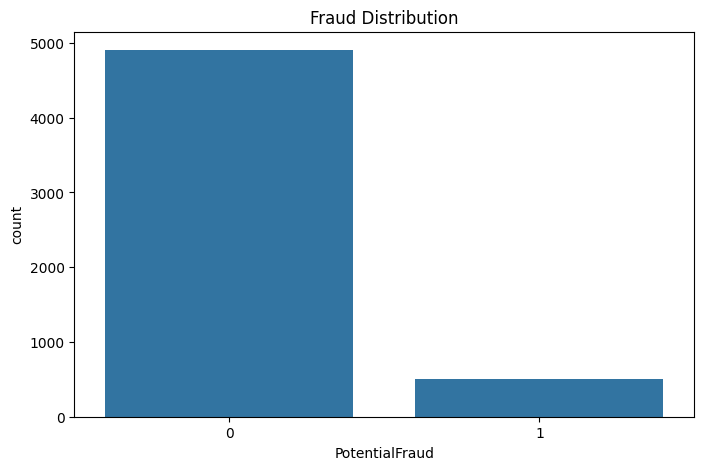

In [51]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="PotentialFraud",
    data=dataset
)

plt.title("Fraud Distribution")
plt.show()

In [52]:
fraud_percentage = (
    dataset["PotentialFraud"]
    .value_counts(normalize=True)
    * 100
)

print(fraud_percentage)

PotentialFraud
0    90.64695
1     9.35305
Name: proportion, dtype: float64


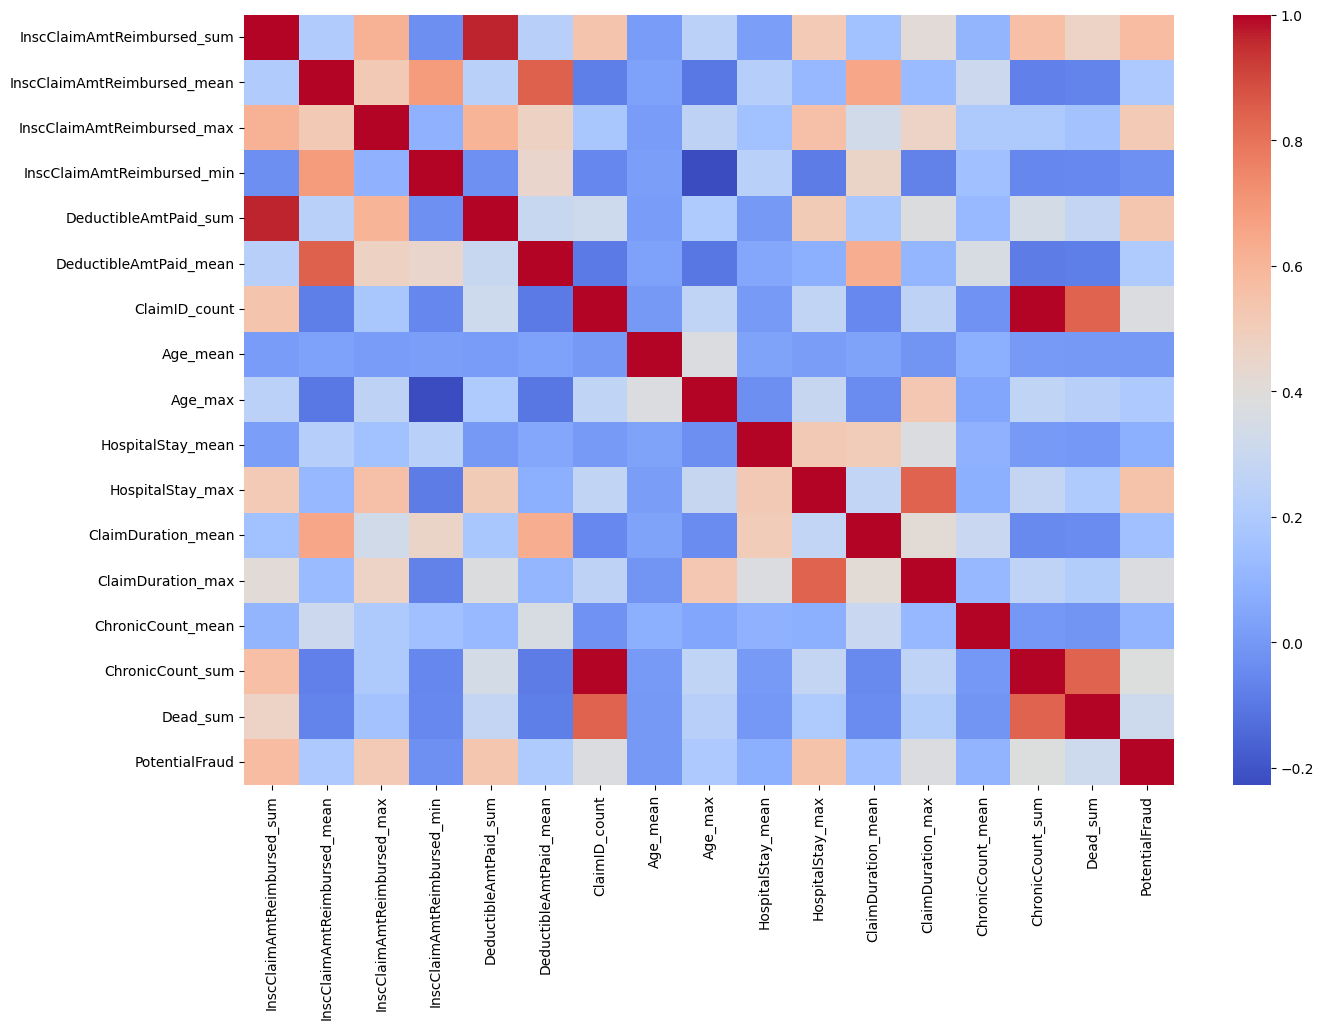

In [53]:
plt.figure(figsize=(15, 10))

sns.heatmap(
    dataset.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.show()

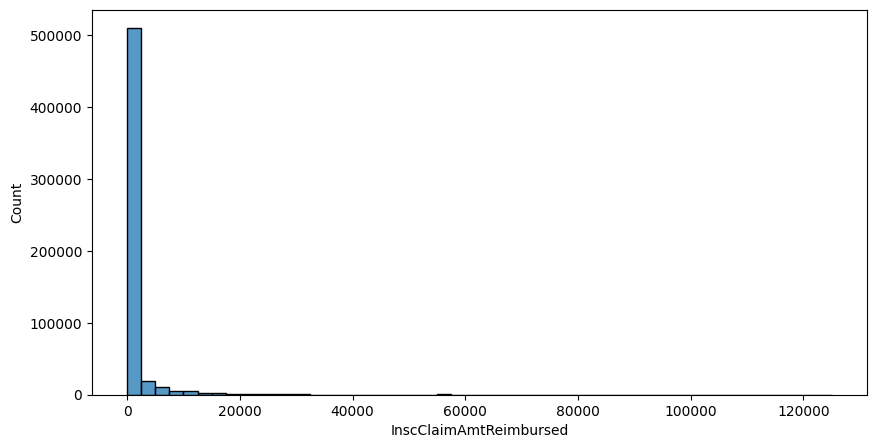

In [54]:
plt.figure(figsize=(10, 5))

sns.histplot(
    claims["InscClaimAmtReimbursed"],
    bins=50
)

plt.show()

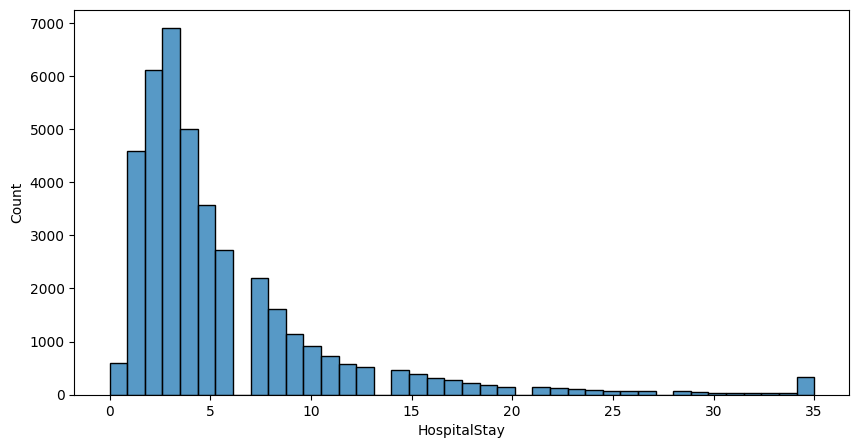

In [55]:
plt.figure(figsize=(10, 5))

sns.histplot(
    claims["HospitalStay"],
    bins=40
)

plt.show()

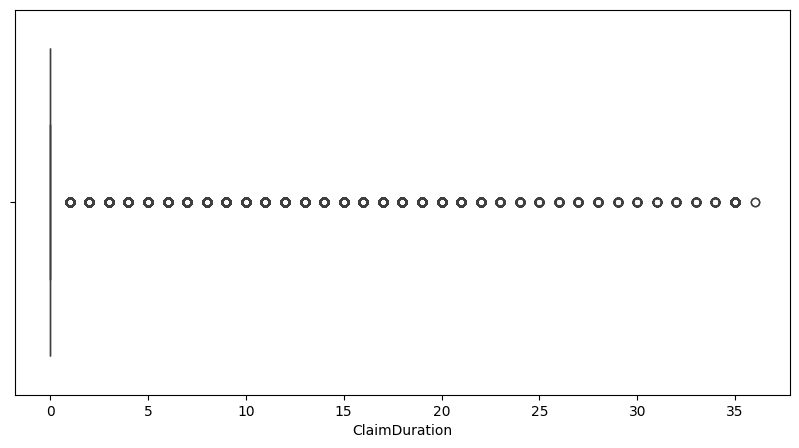

In [56]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=claims["ClaimDuration"]
)

plt.show()

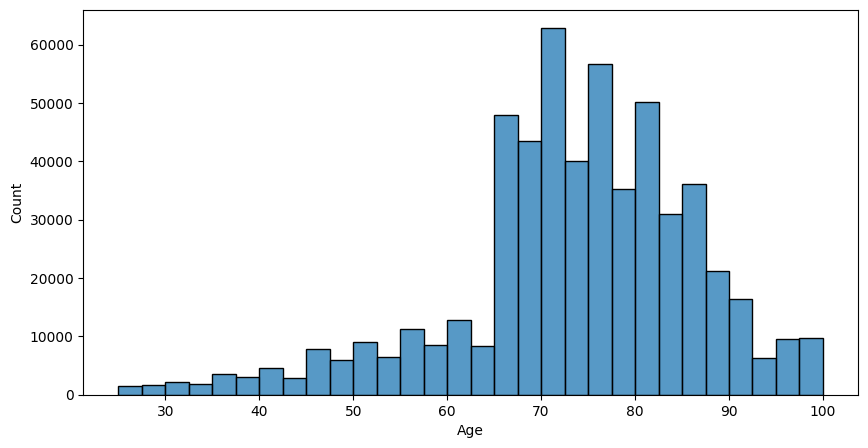

In [57]:
plt.figure(figsize=(10, 5))

sns.histplot(
    claims["Age"],
    bins=30
)

plt.show()

In [58]:
claims["Gender"].value_counts()

Gender
2    323114
1    235097
Name: count, dtype: int64

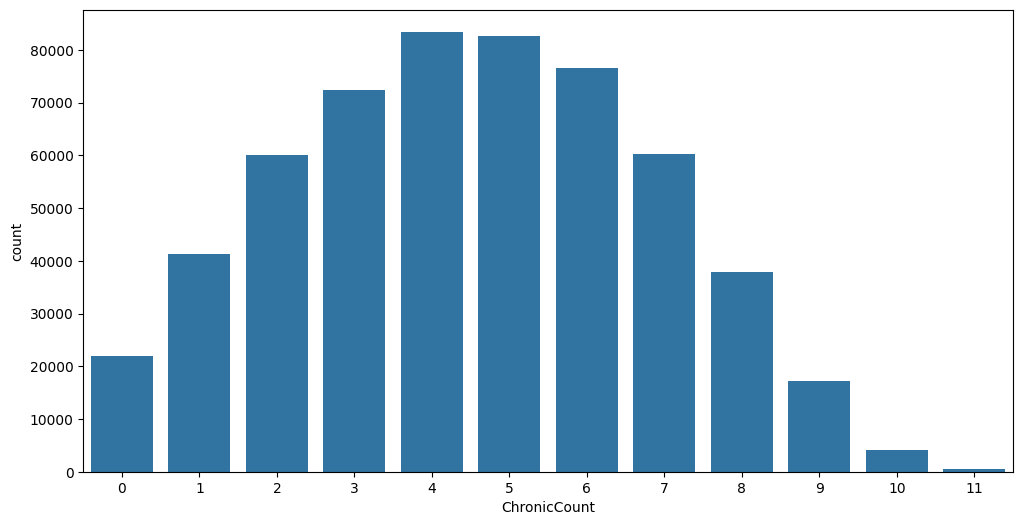

In [59]:
plt.figure(figsize=(12, 6))

sns.countplot(
    x="ChronicCount",
    data=claims
)

plt.show()

In [60]:
top_providers = (
    claims.groupby("Provider")
    ["InscClaimAmtReimbursed"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

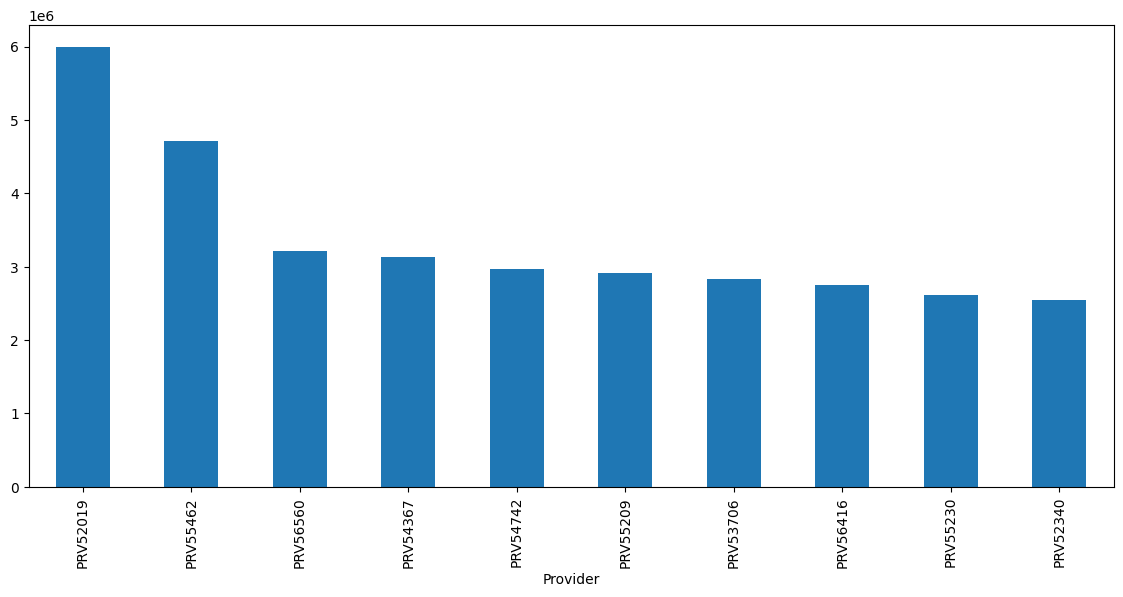

In [61]:
plt.figure(figsize=(14, 6))

top_providers.plot(kind="bar")

plt.show()

In [62]:
state_counts = (
    claims["State"]
    .value_counts()
    .head(10)
)

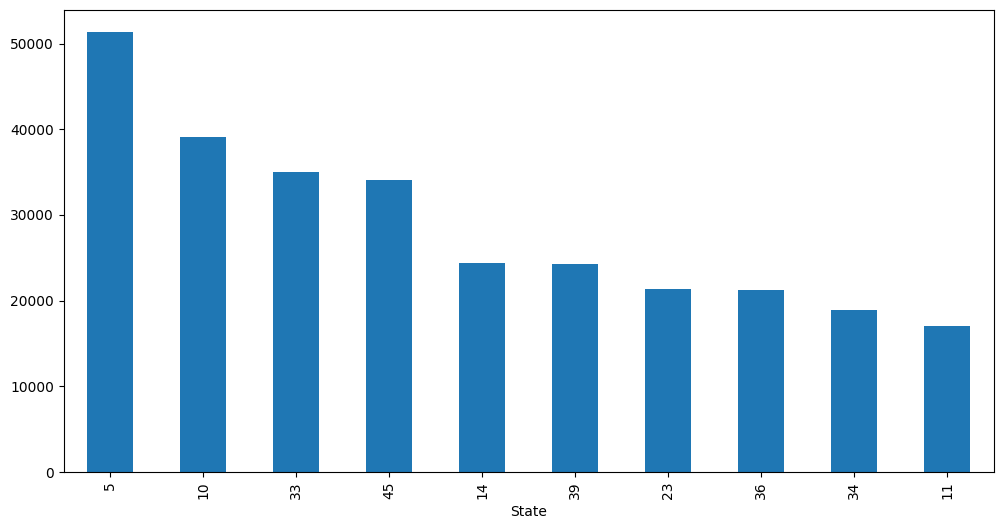

In [63]:
plt.figure(figsize=(12, 6))

state_counts.plot(kind="bar")

plt.show()

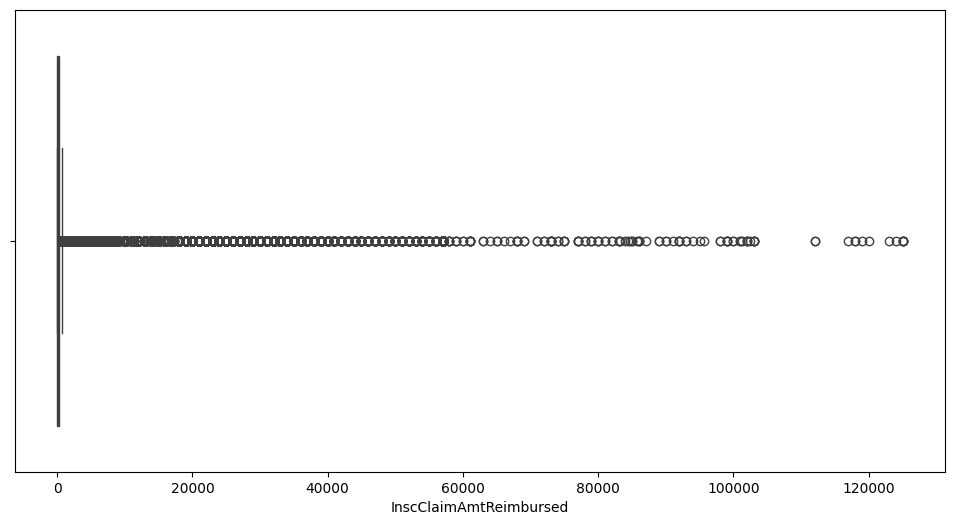

In [64]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x=claims["InscClaimAmtReimbursed"]
)

plt.show()

# Feature Selection

The purpose of feature selection is to identify the most informative variables while reducing noise and redundancy.

This improves model performance and reduces overfitting.

In [65]:
X = dataset.drop(
    columns=["Provider", "PotentialFraud"]
)

y = dataset["PotentialFraud"]

In [66]:
X = X.fillna(0)

In [67]:
print(X.shape)
print(y.shape)

(5410, 16)
(5410,)


In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [69]:
from sklearn.linear_model import LogisticRegression

In [70]:
log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(X_train, y_train)

predictions = log_model.predict(X_test)

In [71]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       981
           1       0.80      0.59      0.68       101

    accuracy                           0.95      1082
   macro avg       0.88      0.79      0.83      1082
weighted avg       0.94      0.95      0.94      1082



In [72]:
from sklearn.ensemble import RandomForestClassifier

In [73]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

In [74]:
rf_model.fit(
    X_train,
    y_train
)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [210]:
import joblib

pipeline = {
    "model": rf_model,
    "features": list(X.columns)
}

joblib.dump(
    pipeline,
    "models/fraud_pipeline.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [75]:
rf_predictions = rf_model.predict(
    X_test
)

In [76]:
print(
    classification_report(
        y_test,
        rf_predictions
    )
)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       981
           1       0.78      0.62      0.69       101

    accuracy                           0.95      1082
   macro avg       0.87      0.80      0.83      1082
weighted avg       0.94      0.95      0.95      1082



In [77]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

In [78]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

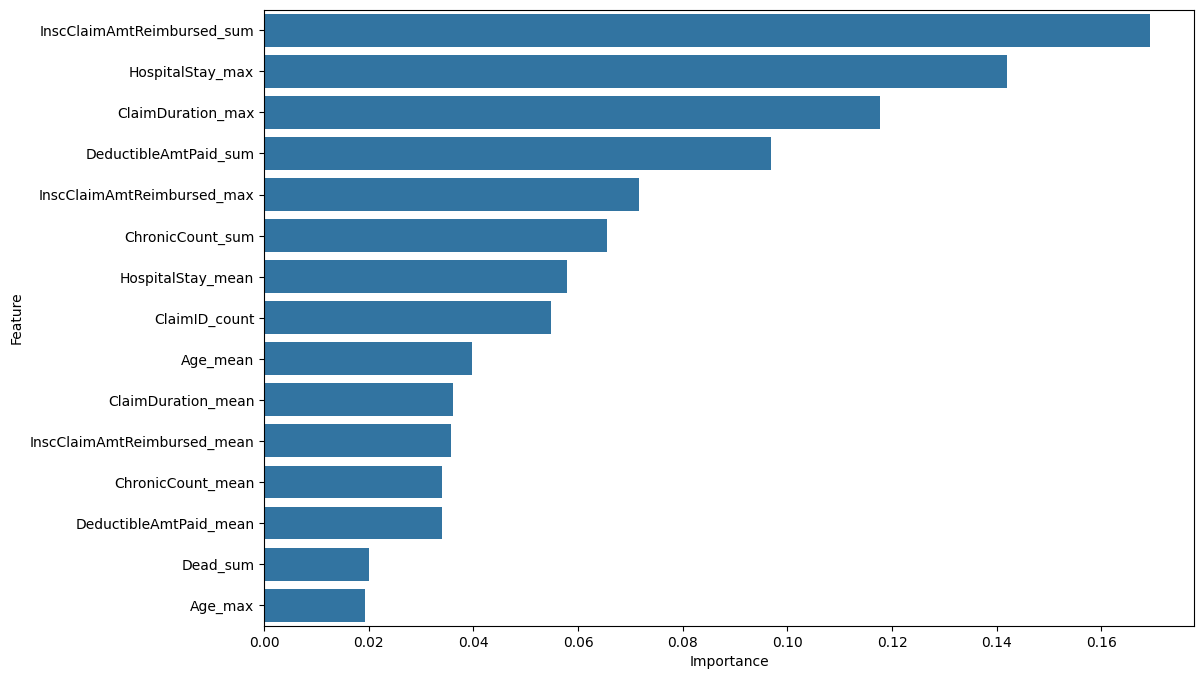

In [79]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(15)
)

plt.show()

In [80]:
from xgboost import XGBClassifier

print("XGBoost loaded successfully")

XGBoost loaded successfully


In [81]:
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05
)

In [82]:
xgb_model.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [83]:
xgb_predictions = xgb_model.predict(
    X_test
)

In [84]:
print(
    classification_report(
        y_test,
        xgb_predictions
    )
)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       981
           1       0.77      0.58      0.66       101

    accuracy                           0.94      1082
   macro avg       0.86      0.78      0.82      1082
weighted avg       0.94      0.94      0.94      1082



In [85]:
from lightgbm import LGBMClassifier

In [86]:
lgb_model = LGBMClassifier(
    random_state=42,
    n_estimators=500
)

In [87]:
lgb_model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Number of positive: 405, number of negative: 3923
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000685 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2884
[LightGBM] [Info] Number of data points in the train set: 4328, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.093577 -> initscore=-2.270725
[LightGBM] [Info] Start training from score -2.270725


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [88]:
lgb_predictions = lgb_model.predict(
    X_test
)

In [89]:
print(
    classification_report(
        y_test,
        lgb_predictions
    )
)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       981
           1       0.79      0.62      0.70       101

    accuracy                           0.95      1082
   macro avg       0.87      0.80      0.83      1082
weighted avg       0.95      0.95      0.95      1082



In [90]:
from sklearn.model_selection import GridSearchCV

In [91]:
parameters = {

    "max_depth": [5, 7, 10],

    "n_estimators": [100, 300, 500],

    "min_samples_split": [2, 5]
}

In [92]:
grid_search = GridSearchCV(
    rf_model,
    parameters,
    cv=5,
    scoring="f1"
)

In [93]:
grid_search.fit(
    X_train,
    y_train
)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 7, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 300, ...]}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [94]:
print(grid_search.best_params_)

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 500}


In [95]:
from sklearn.metrics import confusion_matrix

In [96]:
cm = confusion_matrix(
    y_test,
    rf_predictions
)

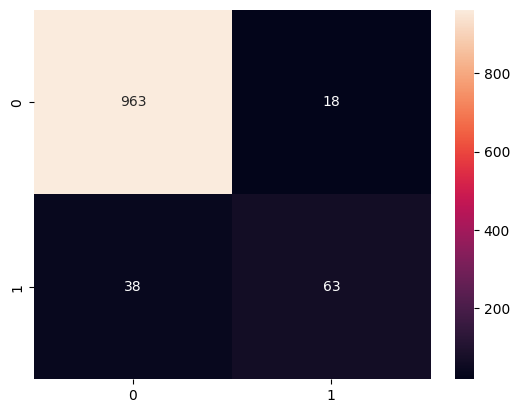

In [97]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.show()

In [99]:
import shap

In [100]:
explainer = shap.TreeExplainer(
    rf_model
)

In [101]:
shap_values = explainer.shap_values(
    X_test
)

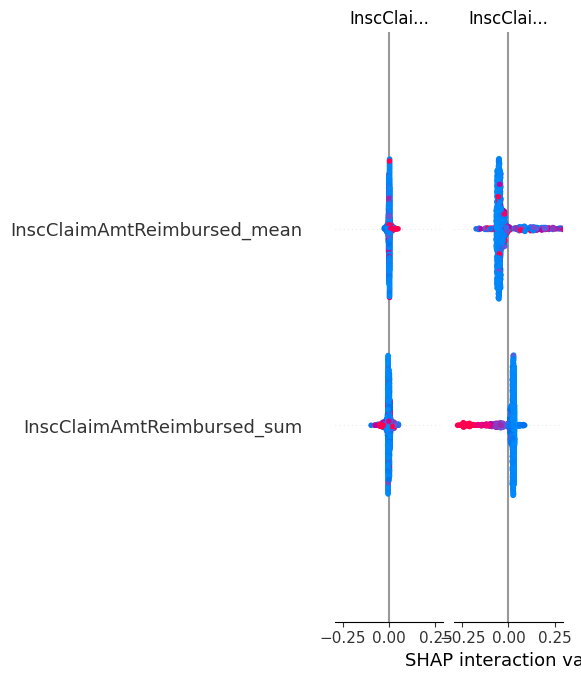

In [102]:
shap.summary_plot(
    shap_values,
    X_test
)

In [103]:
import joblib

In [106]:
pipeline = {
    "model": rf_model,
    "features": list(X.columns)
}

joblib.dump(
    pipeline,
    "models/fraud_pipeline.pkl"
)

['models/fraud_pipeline.pkl']

# Business Recommendations

1. Monitor providers with unusually high reimbursements.

2. Detect repetitive diagnosis patterns.

3. Identify providers with extremely long hospital stays.

4. Implement continuous fraud monitoring.

5. Build real-time fraud detection systems.

6. Perform regular audits.

7. Establish provider risk scores.

# Limitations

1. The model depends heavily on historical data.

2. Fraud patterns continuously evolve.

3. Some fraudulent activities may remain undetected.

4. Data imbalance can affect model performance.

5. Missing values may influence predictions.

6. The model identifies suspicious providers but cannot conclusively prove fraud.

# Conclusion

This project successfully identified potentially fraudulent healthcare providers by analyzing beneficiary information, inpatient claims, and outpatient claims.

Extensive data cleaning, feature engineering, exploratory data analysis, and machine-learning techniques were applied to build an effective fraud detection system.

The final model can assist insurance organizations in identifying suspicious providers, reducing losses, and improving claim management efficiency.